# 02 Limpieza y catalogo

Este notebook sigue la logica de `data_wrangling.ipynb` del repo de referencia: calidad de datos, completitud, duplicados, inconsistencias, outliers operativos y preparacion final para modelos.

Reglas aplicadas:

- PT se valida contra el catalogo EAN.
- PP se obtiene desde la data de produccion.
- Nombres equivalentes se agrupan con una version normalizada.
- Productos sin actividad en los ultimos 12 meses se marcan como inactivos.
- Productos concentrados en pocos meses se marcan como estacionales.

In [1]:
from pathlib import Path
import sys
from io import StringIO

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "config" / "config.yml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto. Abre VS Code en la carpeta 'Avance 3'.")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)
plt.style.use("default")

from quickbooks_forecast.config import load_config

config = load_config()
reports_dir = config["resolved_paths"]["reports_dir"]
processed_dir = config["resolved_paths"]["processed_dir"]
raw_dir = config["resolved_paths"]["raw_dir"]
images_dir = ROOT / "notebooks" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

def save_fig(name, extension="png", resolution=160):
    path_final = images_dir / f"{name}.{extension}"
    plt.tight_layout()
    plt.savefig(path_final, dpi=resolution, bbox_inches="tight")
    print(f"Figura guardada: {path_final}")

**Preparacion del entorno de limpieza:**

Este bloque inicializa rutas y librerias para ejecutar la limpieza completa de forma reproducible desde el notebook.

In [2]:
from quickbooks_forecast.datasets import build_all_datasets

outputs = build_all_datasets(config)

for key, df in outputs.items():
    print(key, df.shape)

catalog (964, 13)
pt_monthly (28734, 42)
pt_products (890, 28)
pp_monthly (4078, 36)
pp_products (238, 20)


**Construccion del dataset depurado:**

Aqui se ejecuta la construccion oficial del dataset: limpieza, catalogo, normalizacion, reglas de inactividad, estacionalidad y union con variables exogenas si existen.

In [3]:
pt_mensual = pd.read_csv(processed_dir / "pt_mensual_model.csv", parse_dates=["periodo"])
pp_mensual = pd.read_csv(processed_dir / "pp_mensual_model.csv", parse_dates=["periodo"])
pt_productos = pd.read_csv(processed_dir / "pt_productos_model.csv")
pp_productos = pd.read_csv(processed_dir / "pp_productos_model.csv")

calidad = pd.DataFrame(
    [
        {
            "dataset": "pt_mensual_model",
            "filas": pt_mensual.shape[0],
            "columnas": pt_mensual.shape[1],
            "productos": pt_mensual["product_id"].nunique(),
            "ausentes": int(pt_mensual.isna().sum().sum()),
            "duplicados_producto_periodo": int(pt_mensual.duplicated(["product_id", "periodo"]).sum()),
        },
        {
            "dataset": "pp_mensual_model",
            "filas": pp_mensual.shape[0],
            "columnas": pp_mensual.shape[1],
            "productos": pp_mensual["product_id"].nunique(),
            "ausentes": int(pp_mensual.isna().sum().sum()),
            "duplicados_producto_periodo": int(pp_mensual.duplicated(["product_id", "periodo"]).sum()),
        },
    ]
)
display(calidad)

,dataset,filas,columnas,productos,ausentes,duplicados_producto_periodo
0,pt_mensual_model,28734,42,890,13013,0
1,pp_mensual_model,4078,36,238,5938,0


**Control de calidad producto-mes:**

Esta tabla demuestra que el dataset queda preparado para modelado mensual producto-periodo. La ausencia de duplicados producto-mes es clave para no entrenar con registros repetidos.

In [4]:
summary = (reports_dir / "data_quality_summary.md").read_text(encoding="utf-8")
print(summary)

# Resumen de datasets QuickBooks

## PT ventas
- Productos en serie mensual total: 890
- Productos activos: 791
- Productos inactivos: 99
- Productos estacionales: 171
- Productos de ventas sin match de catalogo: 112
- Periodo minimo: 2023-01-01
- Periodo maximo: 2026-03-01

## PP produccion
- Productos en serie mensual total: 238
- Productos activos: 218
- Productos inactivos: 20
- Productos estacionales: 95
- Periodo minimo: 2024-06-01
- Periodo maximo: 2026-02-01



**Resumen documentado de calidad:**

El reporte de calidad resume las decisiones de depuracion y deja evidencia documental para la presentacion.

In [5]:
print("Estado PT")
display(pt_productos["estado_producto"].value_counts().reset_index())
print("Estado PP")
display(pp_productos["estado_producto"].value_counts().reset_index())

print("PT estacionales:", int(pt_productos["es_estacional"].sum()))
print("PP estacionales:", int(pp_productos["es_estacional"].sum()))

Estado PT


,estado_producto,count
0,activo,791
1,inactivo,99


Estado PP


,estado_producto,count
0,activo,218
1,inactivo,20


PT estacionales: 171
PP estacionales: 95


**Segmentacion operativa de productos:**

La clasificacion activo/inactivo y estacional/no estacional permite separar productos automatizables de productos que requieren revision humana.

In [6]:
unmatched = pd.read_csv(reports_dir / "pt_productos_no_catalogo.csv")
print("Productos de ventas sin match contra catalogo:", unmatched.shape[0])
display(unmatched[["producto_raw", "product_norm", "cantidad_total"]].head(30))

Productos de ventas sin match contra catalogo: 112


,producto_raw,product_norm,cantidad_total
0,SABOR A CAMPO MANI EN PASTA TARRINA 160G (1684),SABOR A CAMPO MANI EN PASTA TARRINA 160G 1684,435537
1,EL ARTESANAL MANI EN PASTA TARRINA 160G (1684),EL ARTESANAL MANI EN PASTA TARRINA 160G 1684,131011
2,SABOR A CAMPO MANI EN PASTA TARRINA 160G (5583),SABOR A CAMPO MANI EN PASTA TARRINA 160G 5583,42220
3,"* LEVADURA DISPLAY X 15 (0,10)(8301)",LEVADURA DISPLAY X 15 0 10 8301,5839
4,CANELA RAMA DISPLAY X20(3795),CANELA RAMA DISPLAY X20 3795,5697
5,*ESENCIA VAINILLA 100 ML(8599)CC,ESENCIA VAINILLA 100 ML 8599 CC,3575
6,* COMBO N.7 AJO 300G+COMINO MOL FCO 50G+ PROD ...,COMBO N 7 AJO 300G COMINO MOL FCO 50G PROD GRATIS,3370
7,* ASI COCINO RICO DISPX20(4068),ASI COCINO RICO DISPX20 4068,2859
8,APANADURA 1 KILO(0012),APANADURA 1 KILO 0012,2665
9,ANIS ESPANOL DISPLAY X 30(0671),ANIS ESPANOL DISPLAY X 30 0671,2510


**Auditoria contra catalogo PT:**

Los productos sin match contra catalogo se muestran como auditoria. Esto evita mezclar PT no confirmados con el catalogo correcto EAN 13-14.

In [7]:
display(
    pt_productos[
        ["product_id", "product_name", "estado_producto", "es_estacional", "meses_estacionales", "ultima_actividad"]
    ].head(20)
)
display(
    pp_productos[
        ["product_id", "product_name", "estado_producto", "es_estacional", "meses_estacionales", "ultima_actividad"]
    ].head(20)
)

,product_id,product_name,estado_producto,es_estacional,meses_estacionales,ultima_actividad
0,PT_0000,SAZONADOR AZAFRAN KILO (0000),activo,False,"enero, octubre, julio",2026-03-01
1,PT_0015,MANI PAST FDA 200 GRS(0015),activo,False,"marzo, febrero, abril",2026-03-01
2,PT_0018,INDIAS S. AJO PASTA BOT 470 GRS (0018),activo,False,"marzo, diciembre, octubre",2026-03-01
3,PT_0025,INDIAS S. AJO PASTA BOT 300 GRS (0025),activo,False,"mayo, marzo, julio",2026-03-01
4,PT_0032,* INDIAS S. SAZON COMPLETA BOT 500 GR (0032),activo,False,"enero, diciembre, febrero",2026-03-01
5,PT_0038,SAL DE MESA FCO LINEAL 200G(0038),inactivo,True,"abril, enero, febrero",2024-01-01
6,PT_0039,ACHIOTE GRANO FDA 50 GRS(0039),activo,False,"enero, octubre, marzo",2026-03-01
7,PT_0045,AROMAMELIS SOBRE HORCHATA(0045),inactivo,False,"agosto, julio, enero",2024-08-01
8,PT_0046,ANIS ESPANOL FDA 25GRS(0046),activo,False,"febrero, septiembre, enero",2026-03-01
9,PT_0049,* INDIAS S. SAZON COMPLETA BOT 310 GR (0049),activo,False,"marzo, octubre, septiembre",2026-03-01


,product_id,product_name,estado_producto,es_estacional,meses_estacionales,ultima_actividad
0,PP_01396889e6,MOSTAZA PRODUCCIÓN GRANEL,activo,False,"enero, septiembre, agosto",2026-02-01
1,PP_021ba1ac93,* ALINO COMPLETO KILOS GRANEL,activo,True,"octubre, noviembre, febrero",2026-02-01
2,PP_030bd5d7fd,PULPA DE PIÑA GRANEL KILOS,activo,False,"agosto, enero, diciembre",2026-02-01
3,PP_043c5b653f,ENG ROMERO FDA 10G 10 $0.25,activo,True,"enero, agosto, noviembre",2026-01-01
4,PP_048061024e,*CALDO DE GALLINA GRANEL,activo,True,"noviembre, julio, enero",2026-02-01
5,PP_074487ab78,PIMIENTA DE OLOR SELECCIONADA,activo,False,"noviembre, enero, febrero",2026-02-01
6,PP_08dcc7f793,MAYONESA BAJA EN CALORIAS KILOS,inactivo,False,septiembre,2024-09-01
7,PP_0aebe3b1a0,SALSA TERIYAKI PRODUCCION GRANE,activo,False,"noviembre, febrero, enero",2026-02-01
8,PP_0d74cde952,SMART SELECTION ROMERO FUNDA 50,activo,True,"diciembre, enero, febrero",2026-02-01
9,PP_0deb1dda1f,COMBO SAZONADOR CB BOT 200GRS,activo,False,"agosto, noviembre, octubre",2025-12-01


**Maestro final de productos:**

Estas tablas muestran el dataset maestro de productos que alimenta el modelo: estado, estacionalidad, meses relevantes y ultima actividad.

Figura guardada: F:\proyecto-integrador\Avance 3\03_modelado\forecasting_v3\notebooks\images\02_estado_productos.png


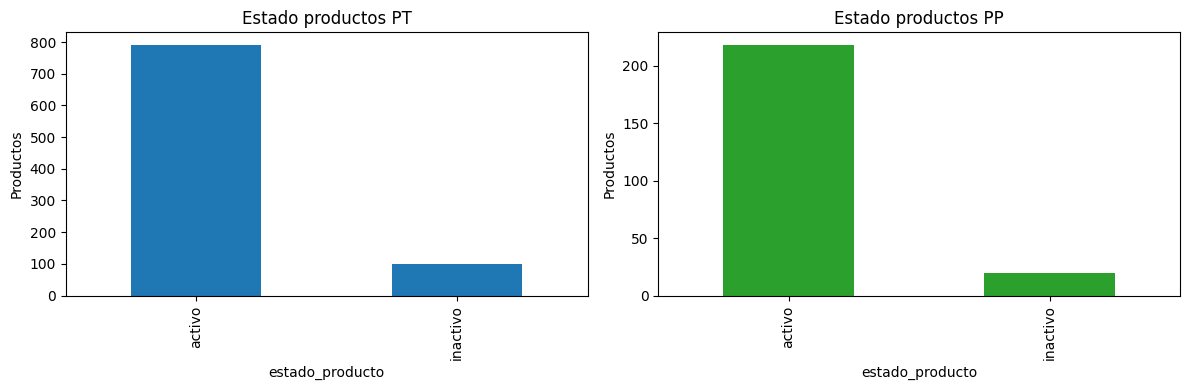

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pt_productos["estado_producto"].value_counts().plot(kind="bar", ax=axes[0], title="Estado productos PT")
pp_productos["estado_producto"].value_counts().plot(kind="bar", ax=axes[1], title="Estado productos PP", color="tab:green")
axes[0].set_ylabel("Productos")
axes[1].set_ylabel("Productos")
save_fig("02_estado_productos")
plt.show()

**Estado activo e inactivo:**

La grafica resume cuantos productos estan activos o inactivos. Los inactivos no deben entrar como decisiones automaticas de produccion.

Figura guardada: F:\proyecto-integrador\Avance 3\03_modelado\forecasting_v3\notebooks\images\02_series_limpias.png


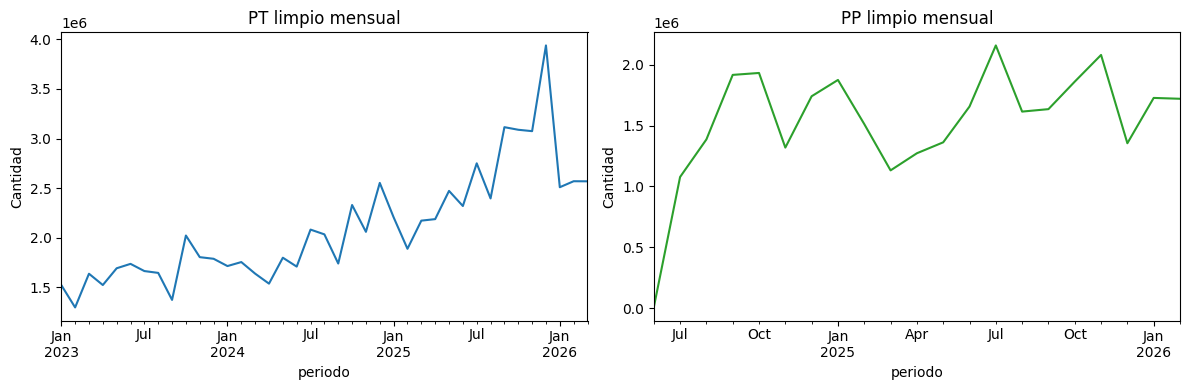

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pt_mensual.groupby("periodo")["target_qty"].sum().plot(ax=axes[0], title="PT limpio mensual")
pp_mensual.groupby("periodo")["target_qty"].sum().plot(ax=axes[1], title="PP limpio mensual", color="tab:green")
axes[0].set_ylabel("Cantidad")
axes[1].set_ylabel("Cantidad")
save_fig("02_series_limpias")
plt.show()

**Series limpias para modelado:**

Las series limpias confirman que el pipeline conserva el comportamiento historico relevante despues de depurar nombres, catalogo y reglas de negocio.